In [22]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
import pandas as pd
attractor_stim = pd.read_csv("../../data/eval/attractors/attractor_stimuli.csv")

for cond, group in attractor_stim.groupby("condition", sort=False):
    print("=" * 60)
    print(f"CONDITION: {cond}")
    for _, row in group.head(2).iterrows():
        print(f"  good: {row['good']}")
        print(f"  bad:  {row['bad']}")

CONDITION: subj_sg
  good: The [wug] is happy.
  bad:  The [wug] are happy.
  good: The [wug] is happy.
  bad:  The [wug] are happy.
CONDITION: subj_pl
  good: The [wugs] are happy.
  bad:  The [wugs] is happy.
  good: The [wugs] are happy.
  bad:  The [wugs] is happy.
CONDITION: subj_sg_d1_pl
  good: The [wug] near the trees is happy.
  bad:  The [wug] near the trees are happy.
  good: The [wug] behind the cars is happy.
  bad:  The [wug] behind the cars are happy.
CONDITION: subj_pl_d1_sg
  good: The [wugs] near the tree are happy.
  bad:  The [wugs] near the tree is happy.
  good: The [wugs] behind the car are happy.
  bad:  The [wugs] behind the car is happy.
CONDITION: subj_sg_d1_pl_d2_pl
  good: The [wug] near the trees and behind the cars is happy.
  bad:  The [wug] near the trees and behind the cars are happy.
  good: The [wug] behind the cars and under the boxes is happy.
  bad:  The [wug] behind the cars and under the boxes are happy.
CONDITION: subj_pl_d1_sg_d2_sg
  good: Th

## Distractor sequence likelihood differences   

               model train_condition   number  distractors  mean_good  mean_bad    margin   n
Qwen3-VL-2B-Instruct          syntax   plural            0  -6.270380 -6.998641  0.728261 230
Qwen3-VL-2B-Instruct          syntax   plural            1  -7.184918 -7.571467  0.386549 230
Qwen3-VL-2B-Instruct          syntax   plural            2  -7.293207 -7.703397  0.410190 230
Qwen3-VL-2B-Instruct          syntax   plural            3  -6.587228 -6.871875  0.284647 230
Qwen3-VL-2B-Instruct          syntax   plural            4  -6.326359 -6.543071  0.216712 230
Qwen3-VL-2B-Instruct          syntax singular            0  -6.370924 -6.907609  0.536685 230
Qwen3-VL-2B-Instruct          syntax singular            1  -7.375136 -7.621875  0.246739 230
Qwen3-VL-2B-Instruct          syntax singular            2  -7.862092 -7.932201  0.070109 230
Qwen3-VL-2B-Instruct          syntax singular            3  -7.061685 -7.085190  0.023505 230
Qwen3-VL-2B-Instruct          syntax singular            4  

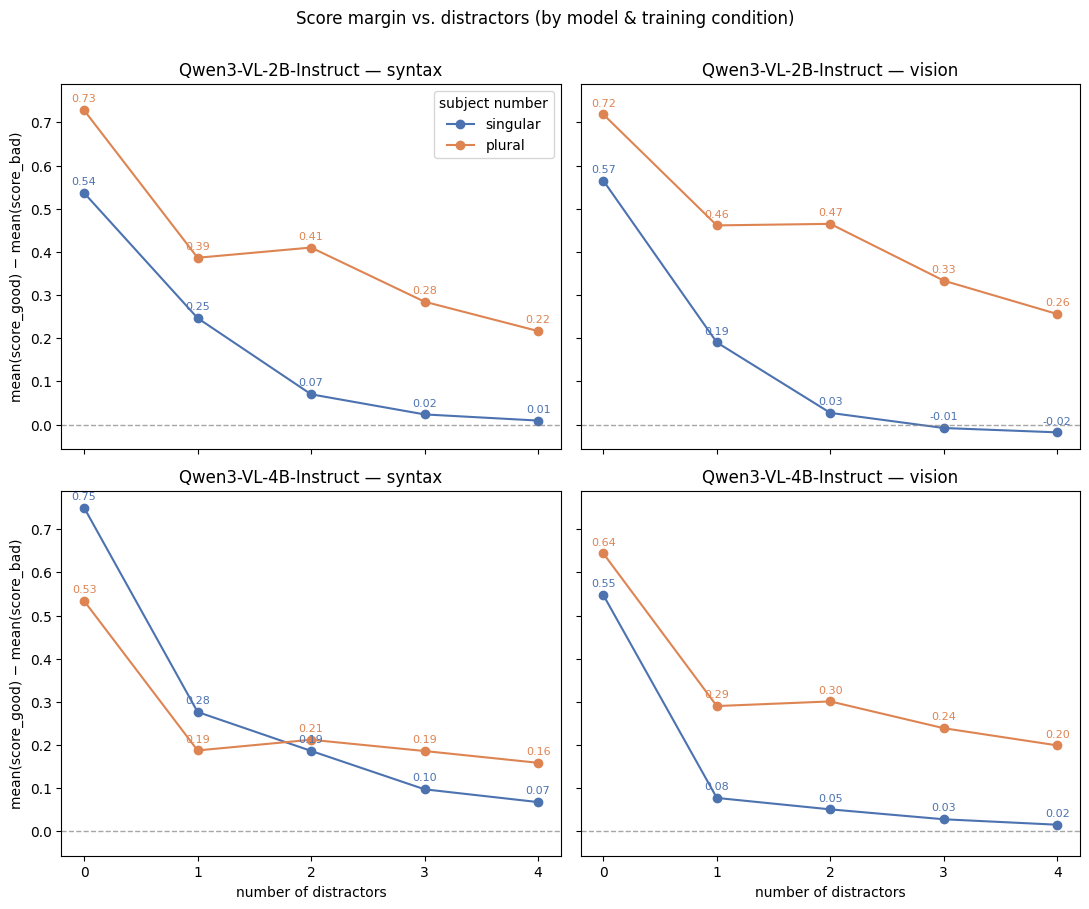

In [25]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_ROOT = "../../results/eval/attractors"
OUT_PNG = "../../results/eval/attractors/margin_by_distractors.png"

TRAIN_CONDITIONS = ["syntax", "vision"]
NUMBERS = ["singular", "plural"]
COLORS = {"singular": "#4C72B0", "plural": "#DD8452"}


def classify_number(good):
    """Singular if subject is [wug], plural if [wugs]. Check [wugs] first
    since '[wug]' is a substring of '[wugs]'."""
    s = str(good)
    if "[wugs]" in s:
        return "plural"
    if "[wug]" in s:
        return "singular"
    return "unknown"


# --- Collect all scored CSVs ---
paths = glob.glob(os.path.join(RESULTS_ROOT, "*", "*", "*scored*.csv"))
assert paths, f"No scored CSVs found under {RESULTS_ROOT}"

records = []
for p in sorted(paths):
    parts = p.split(os.sep)
    model = parts[-3]
    train_condition = parts[-2]

    df = pd.read_csv(p)
    df["score_good"] = df["score_good"].astype(float)
    df["score_bad"] = df["score_bad"].astype(float)
    df["number"] = df["good"].apply(classify_number)

    # mean(score_good) - mean(score_bad) by (number, distractors)
    for (number, distr), grp in df.groupby(["number", "distractors"]):
        mg = grp["score_good"].mean()
        mb = grp["score_bad"].mean()
        records.append({
            "model": model, "train_condition": train_condition,
            "number": number, "distractors": int(distr),
            "mean_good": mg, "mean_bad": mb, "margin": mg - mb, "n": len(grp),
        })

summary = pd.DataFrame(records)
print(summary.sort_values(["model", "train_condition", "number", "distractors"]).to_string(index=False))

# --- Plot grid: rows = models, cols = train_conditions; x = distractors, line per number ---
models = sorted(summary["model"].unique())
all_distractors = sorted(summary["distractors"].unique())

nrows, ncols = len(models), len(TRAIN_CONDITIONS)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                         sharey=True, sharex=True, squeeze=False)

for r, model in enumerate(models):
    for c, tc in enumerate(TRAIN_CONDITIONS):
        ax = axes[r][c]
        sub = summary[(summary["model"] == model) & (summary["train_condition"] == tc)]
        for number in NUMBERS:
            s = sub[sub["number"] == number].sort_values("distractors")
            if len(s):
                ax.plot(s["distractors"], s["margin"], marker="o",
                        label=number, color=COLORS[number])
                for _, row in s.iterrows():
                    ax.annotate(f"{row['margin']:.2f}",
                                (row["distractors"], row["margin"]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=8, color=COLORS[number])
        ax.axhline(0.0, ls="--", color="gray", lw=1, alpha=0.7)
        ax.set_xticks(all_distractors)
        ax.set_title(f"{model} — {tc}")
        if r == nrows - 1:
            ax.set_xlabel("number of distractors")
        if c == 0:
            ax.set_ylabel("mean(score_good) − mean(score_bad)")

axes[0][0].legend(title="subject number")
fig.suptitle("Score margin vs. distractors (by model & training condition)", y=1.005)
fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved plot to {OUT_PNG}")

## Distractor sequence accuracies   

               model train_condition   number  distractors  accuracy   n
Qwen3-VL-2B-Instruct          syntax   plural            0  1.000000 230
Qwen3-VL-2B-Instruct          syntax   plural            1  0.965217 230
Qwen3-VL-2B-Instruct          syntax   plural            2  1.000000 230
Qwen3-VL-2B-Instruct          syntax   plural            3  0.978261 230
Qwen3-VL-2B-Instruct          syntax   plural            4  0.973913 230
Qwen3-VL-2B-Instruct          syntax singular            0  0.913043 230
Qwen3-VL-2B-Instruct          syntax singular            1  0.826087 230
Qwen3-VL-2B-Instruct          syntax singular            2  0.565217 230
Qwen3-VL-2B-Instruct          syntax singular            3  0.413043 230
Qwen3-VL-2B-Instruct          syntax singular            4  0.352174 230
Qwen3-VL-2B-Instruct          vision   plural            0  1.000000 230
Qwen3-VL-2B-Instruct          vision   plural            1  0.995652 230
Qwen3-VL-2B-Instruct          vision   plural      

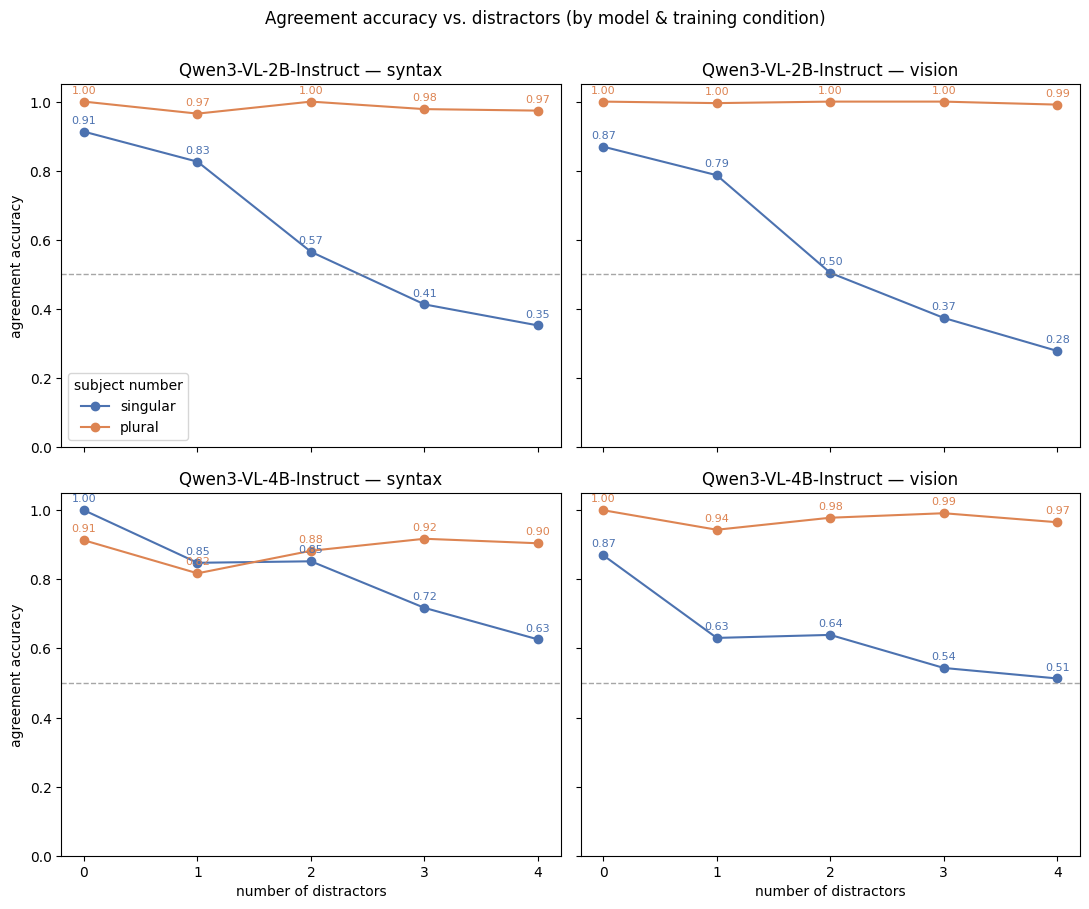

In [26]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_ROOT = "../../results/eval/attractors"
OUT_PNG = "../../results/eval/attractors/accuracy_by_distractors.png"

TRAIN_CONDITIONS = ["syntax", "vision"]
NUMBERS = ["singular", "plural"]
COLORS = {"singular": "#4C72B0", "plural": "#DD8452"}


def classify_number(good):
    """Singular if subject is [wug], plural if [wugs]. Check [wugs] first
    since '[wug]' is a substring of '[wugs]'."""
    s = str(good)
    if "[wugs]" in s:
        return "plural"
    if "[wug]" in s:
        return "singular"
    return "unknown"


def coerce_correct(df):
    if "is_correct" in df.columns:
        s = df["is_correct"]
        if s.dtype == bool:
            return s
        return s.astype(str).str.strip().str.lower().isin(["true", "1", "1.0", "yes"])
    return df["score_good"].astype(float) > df["score_bad"].astype(float)


# --- Collect all scored CSVs ---
paths = glob.glob(os.path.join(RESULTS_ROOT, "*", "*", "*scored*.csv"))
assert paths, f"No scored CSVs found under {RESULTS_ROOT}"

records = []
for p in sorted(paths):
    parts = p.split(os.sep)
    model = parts[-3]
    train_condition = parts[-2]

    df = pd.read_csv(p)
    df["is_correct"] = coerce_correct(df)
    df["number"] = df["good"].apply(classify_number)

    # accuracy by (number, distractors)
    for (number, distr), grp in df.groupby(["number", "distractors"]):
        records.append({
            "model": model, "train_condition": train_condition,
            "number": number, "distractors": int(distr),
            "accuracy": grp["is_correct"].mean(), "n": len(grp),
        })

summary = pd.DataFrame(records)
print(summary.sort_values(["model", "train_condition", "number", "distractors"]).to_string(index=False))

# --- Plot grid: rows = models, cols = train_conditions; x = distractors, line per number ---
models = sorted(summary["model"].unique())
all_distractors = sorted(summary["distractors"].unique())

nrows, ncols = len(models), len(TRAIN_CONDITIONS)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                         sharey=True, sharex=True, squeeze=False)

for r, model in enumerate(models):
    for c, tc in enumerate(TRAIN_CONDITIONS):
        ax = axes[r][c]
        sub = summary[(summary["model"] == model) & (summary["train_condition"] == tc)]
        for number in NUMBERS:
            s = sub[sub["number"] == number].sort_values("distractors")
            if len(s):
                ax.plot(s["distractors"], s["accuracy"], marker="o",
                        label=number, color=COLORS[number])
                for _, row in s.iterrows():
                    ax.annotate(f"{row['accuracy']:.2f}",
                                (row["distractors"], row["accuracy"]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=8, color=COLORS[number])
        ax.axhline(0.5, ls="--", color="gray", lw=1, alpha=0.7)
        ax.set_xticks(all_distractors)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"{model} — {tc}")
        if r == nrows - 1:
            ax.set_xlabel("number of distractors")
        if c == 0:
            ax.set_ylabel("agreement accuracy")

axes[0][0].legend(title="subject number")
fig.suptitle("Agreement accuracy vs. distractors (by model & training condition)", y=1.005)
fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved plot to {OUT_PNG}")

               model train_condition          condition       group  accuracy  n
Qwen3-VL-2b-Instruct          syntax complex_subject_np coordinated      0.95 20
Qwen3-VL-2b-Instruct          syntax complex_subject_np   partitive      1.00 20
Qwen3-VL-2b-Instruct          syntax        pseudocleft      plural      1.00 10
Qwen3-VL-2b-Instruct          syntax        pseudocleft    singular      0.80 10
Qwen3-VL-2b-Instruct          syntax  raising_predicate      plural      0.80 10
Qwen3-VL-2b-Instruct          syntax  raising_predicate    singular      0.90 10
Qwen3-VL-2b-Instruct          syntax       tag_question      plural      0.90 10
Qwen3-VL-2b-Instruct          syntax       tag_question    singular      1.00 10
Qwen3-VL-2b-Instruct          vision complex_subject_np coordinated      1.00 20
Qwen3-VL-2b-Instruct          vision complex_subject_np   partitive      1.00 20
Qwen3-VL-2b-Instruct          vision        pseudocleft      plural      1.00 10
Qwen3-VL-2b-Instruct        

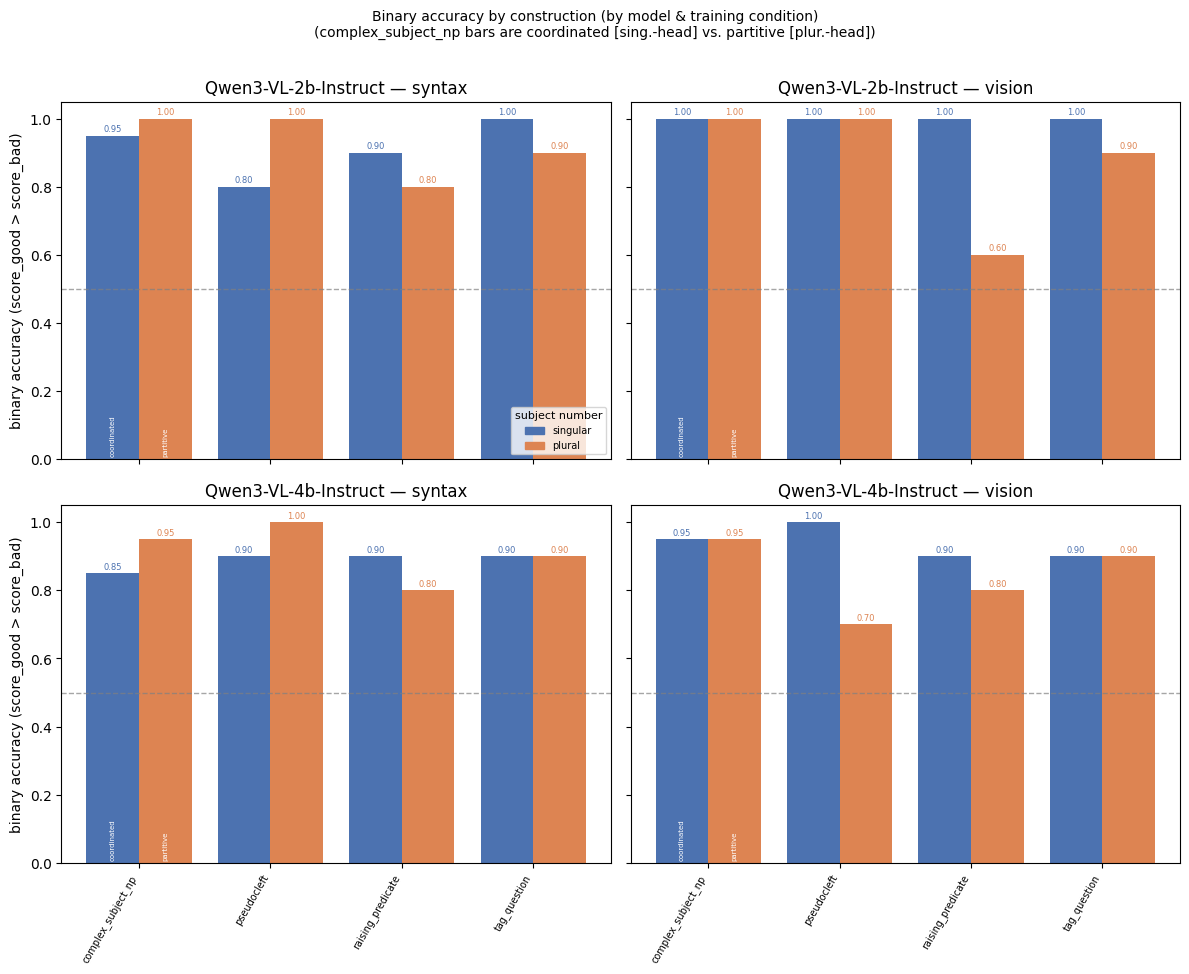

In [35]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scored CSVs live at: RESULTS_ROOT/<model>/<train_condition>/*scored*.csv
RESULTS_ROOT = "../../results/generalization_constructions"
OUT_PNG = "../../results/generalization_constructions/accuracy_by_construction.png"

TRAIN_CONDITIONS = ["syntax", "vision"]
NUMBERS = ["singular", "plural"]
COLORS = {"singular": "#4C72B0", "plural": "#DD8452"}

# Merge related constructions under a single label.
# partitive_subject ("One of the [wugs]...") and coordinated_subject
# ("The [wug] and the bird...") both test agreement driven by a complex
# subject NP rather than the bare head noun.
#
# NOTE: coordinated_subject is ALL [wug] (singular head) and partitive_subject
# is ALL [wugs] (plural head), so the usual singular/plural split is not a real
# within-frame contrast here. For the merged label we instead keep the two as
# distinct sub-types and color them separately.
MERGE_CONSTRUCTIONS = {
    "partitive_subject": "complex_subject_np",
    "coordinated_subject": "complex_subject_np",
}
MERGED_LABEL = "complex_subject_np"
# For the merged construction, override the bar grouping: which original
# construction each row came from, so the two bars stay meaningful.
SUBTYPE_OF = {
    "coordinated_subject": "coordinated",
    "partitive_subject": "partitive",
}
SUBTYPE_COLORS = {"coordinated": "#4C72B0", "partitive": "#DD8452"}


def classify_number(good):
    """Singular if subject is [wug], plural if [wugs]. Check [wugs] first
    since '[wug]' is a substring of '[wugs]'."""
    s = str(good)
    if "[wugs]" in s:
        return "plural"
    if "[wug]" in s:
        return "singular"
    return "unknown"


# --- Collect all scored CSVs ---
paths = glob.glob(os.path.join(RESULTS_ROOT, "*", "*", "*scored*.csv"))
assert paths, f"No scored CSVs found under {RESULTS_ROOT}"

records = []
for p in sorted(paths):
    parts = p.split(os.sep)
    model = parts[-3]
    train_condition = parts[-2]

    df = pd.read_csv(p)
    df["number"] = df["good"].apply(classify_number)
    # is_correct is already in the CSV; coerce to float so .mean() = accuracy.
    df["is_correct"] = df["is_correct"].astype(bool).astype(float)

    # The grouping that defines the two bars per construction.
    # Normally this is singular/plural. For merged constructions where each
    # sub-type is single-number, we group by sub-type instead.
    df["group"] = df["number"]
    is_merged = df["condition"].isin(MERGE_CONSTRUCTIONS)
    df.loc[is_merged, "group"] = df.loc[is_merged, "condition"].map(SUBTYPE_OF)
    # Apply the merge to the condition label itself.
    df["condition"] = df["condition"].replace(MERGE_CONSTRUCTIONS)

    # binary accuracy per (construction, group)
    for (cond, group), grp in df.groupby(["condition", "group"]):
        records.append({
            "model": model, "train_condition": train_condition,
            "condition": cond, "group": group,
            "accuracy": grp["is_correct"].mean(), "n": len(grp),
        })

summary = pd.DataFrame(records)
print(summary.sort_values(["model", "train_condition", "condition", "group"]).to_string(index=False))

# --- Plot grid: rows = models, cols = train_conditions ---
# Each subplot: x = construction, two bars per construction.
# For normal constructions the two bars are singular/plural; for the merged
# complex_subject_np they are the coordinated/partitive sub-types.
models = sorted(summary["model"].unique())
constructions = sorted(summary["condition"].unique())
x = np.arange(len(constructions))
bar_w = 0.4

# Left/right group identity for each construction.
def groups_for(cond):
    if cond == MERGED_LABEL:
        return ["coordinated", "partitive"]
    return ["singular", "plural"]

GROUP_COLORS = {**COLORS, **SUBTYPE_COLORS}

nrows, ncols = len(models), len(TRAIN_CONDITIONS)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(max(12, 0.5 * len(constructions) * ncols), 4.8 * nrows),
    sharey=True, sharex=True, squeeze=False,
)

for r, model in enumerate(models):
    for c, tc in enumerate(TRAIN_CONDITIONS):
        ax = axes[r][c]
        sub = summary[(summary["model"] == model) & (summary["train_condition"] == tc)]
        lut = sub.set_index(["condition", "group"])["accuracy"]

        for ci, cond in enumerate(constructions):
            for side, grp in enumerate(groups_for(cond)):
                v = lut.get((cond, grp), np.nan)
                if np.isnan(v):
                    continue
                offset = (side - 0.5) * bar_w
                ax.bar(x[ci] + offset, v, width=bar_w, color=GROUP_COLORS[grp])
                ax.annotate(f"{v:.2f}", (x[ci] + offset, v),
                            textcoords="offset points", xytext=(0, 3),
                            ha="center", fontsize=6, color=GROUP_COLORS[grp])
                # label the merged sub-type bars since they aren't singular/plural
                if cond == MERGED_LABEL:
                    ax.annotate(grp, (x[ci] + offset, 0),
                                textcoords="offset points", xytext=(0, 2),
                                ha="center", va="bottom", fontsize=5,
                                rotation=90, color="white")

        ax.axhline(0.5, ls="--", color="gray", lw=1, alpha=0.7)  # chance
        ax.set_ylim(0, 1.05)
        ax.set_title(f"{model} — {tc}")
        ax.set_xticks(x)
        if r == nrows - 1:
            ax.set_xticklabels(constructions, rotation=60, ha="right", fontsize=7)
        if c == 0:
            ax.set_ylabel("binary accuracy (score_good > score_bad)")

# Legend: singular/plural are the common case; note the merged exception.
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=COLORS["singular"], label="singular"),
    Patch(color=COLORS["plural"], label="plural"),
]
axes[0][0].legend(handles=legend_handles, title="subject number",
                  fontsize=7, title_fontsize=8)
fig.suptitle("Binary accuracy by construction (by model & training condition)\n"
             "(complex_subject_np bars are coordinated [sing.-head] vs. partitive [plur.-head])",
             y=1.01, fontsize=10)
fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved plot to {OUT_PNG}")

               model train_condition   number  accuracy    ci_lo    ci_hi  n
Qwen3-VL-2b-Instruct          syntax   plural      0.94 0.837827 0.979385 50
Qwen3-VL-2b-Instruct          syntax singular      0.92 0.811615 0.968451 50
Qwen3-VL-2b-Instruct          vision   plural      0.90 0.786395 0.956525 50
Qwen3-VL-2b-Instruct          vision singular      1.00 0.928650 1.000000 50
Qwen3-VL-4b-Instruct          syntax   plural      0.92 0.811615 0.968451 50
Qwen3-VL-4b-Instruct          syntax singular      0.88 0.761949 0.943825 50
Qwen3-VL-4b-Instruct          vision   plural      0.86 0.738135 0.930493 50
Qwen3-VL-4b-Instruct          vision singular      0.94 0.837827 0.979385 50

Saved plot to ../../results/generalization_constructions/accuracy_aggregate.png


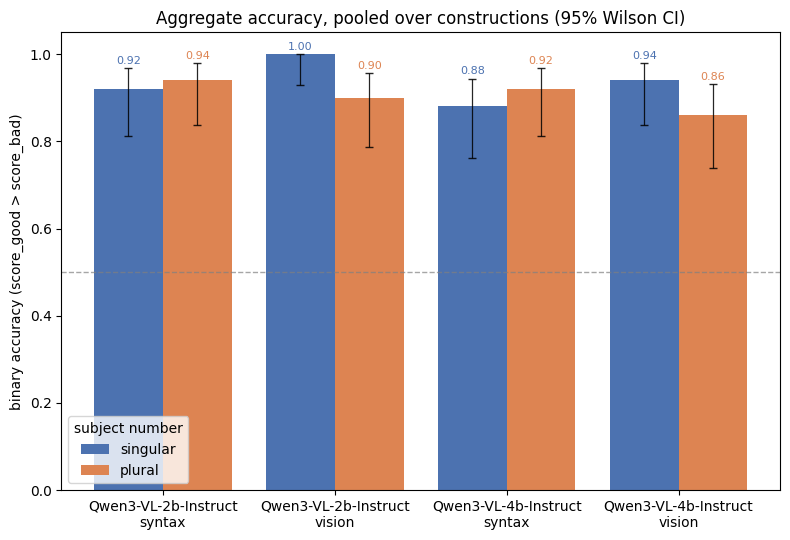

In [36]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scored CSVs live at: RESULTS_ROOT/<model>/<train_condition>/*scored*.csv
RESULTS_ROOT = "../../results/generalization_constructions"
OUT_PNG = "../../results/generalization_constructions/accuracy_aggregate.png"

TRAIN_CONDITIONS = ["syntax", "vision"]
NUMBERS = ["singular", "plural"]
COLORS = {"singular": "#4C72B0", "plural": "#DD8452"}


def classify_number(good):
    """Singular if subject is [wug], plural if [wugs]. Check [wugs] first
    since '[wug]' is a substring of '[wugs]'."""
    s = str(good)
    if "[wugs]" in s:
        return "plural"
    if "[wug]" in s:
        return "singular"
    return "unknown"


def wilson_ci(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion. Returns (lo, hi)."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    return (center - half, center + half)


# --- Collect all scored CSVs ---
paths = glob.glob(os.path.join(RESULTS_ROOT, "*", "*", "*scored*.csv"))
assert paths, f"No scored CSVs found under {RESULTS_ROOT}"

# Pool every pair across constructions, keeping only the model / modality / number split.
rows_all = []
for p in sorted(paths):
    parts = p.split(os.sep)
    model = parts[-3]
    train_condition = parts[-2]

    df = pd.read_csv(p)
    df["number"] = df["good"].apply(classify_number)
    df["is_correct"] = df["is_correct"].astype(bool).astype(float)
    df["model"] = model
    df["train_condition"] = train_condition
    rows_all.append(df[["model", "train_condition", "number", "is_correct"]])

pool = pd.concat(rows_all, ignore_index=True)

records = []
for (model, tc, number), grp in pool.groupby(["model", "train_condition", "number"]):
    k = int(grp["is_correct"].sum())
    n = len(grp)
    acc = k / n if n else np.nan
    lo, hi = wilson_ci(k, n)
    records.append({
        "model": model, "train_condition": tc, "number": number,
        "accuracy": acc, "ci_lo": lo, "ci_hi": hi, "n": n,
    })

summary = pd.DataFrame(records)
print(summary.sort_values(["model", "train_condition", "number"]).to_string(index=False))

# --- Plot: x = model x modality cell, two bars (singular/plural) per cell ---
models = sorted(summary["model"].unique())
cells = [(m, tc) for m in models for tc in TRAIN_CONDITIONS]
labels = [f"{m}\n{tc}" for m, tc in cells]
x = np.arange(len(cells))
bar_w = 0.4

fig, ax = plt.subplots(figsize=(max(8, 2.0 * len(cells)), 5.5))

for i, number in enumerate(NUMBERS):
    vals, los, his = [], [], []
    for m, tc in cells:
        row = summary[(summary["model"] == m) &
                      (summary["train_condition"] == tc) &
                      (summary["number"] == number)]
        if len(row):
            r = row.iloc[0]
            vals.append(r["accuracy"])
            los.append(max(0.0, r["accuracy"] - max(0.0, r["ci_lo"])))
            his.append(max(0.0, min(1.0, r["ci_hi"]) - r["accuracy"]))
        else:
            vals.append(np.nan); los.append(0.0); his.append(0.0)

    offset = (i - 0.5) * bar_w
    xpos = x + offset
    ax.bar(xpos, vals, width=bar_w, label=number, color=COLORS[number])
    ax.errorbar(xpos, vals, yerr=np.array([los, his]), fmt="none",
                ecolor="black", elinewidth=0.9, capsize=3, alpha=0.85)
    for xi, v, hi in zip(xpos, vals, his):
        if not np.isnan(v):
            ax.annotate(f"{v:.2f}", (xi, v + hi),
                        textcoords="offset points", xytext=(0, 3),
                        ha="center", fontsize=8, color=COLORS[number])

ax.axhline(0.5, ls="--", color="gray", lw=1, alpha=0.7)  # chance
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("binary accuracy (score_good > score_bad)")
ax.set_title("Aggregate accuracy, pooled over constructions (95% Wilson CI)")
ax.legend(title="subject number")
fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved plot to {OUT_PNG}")